In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../..'
data_dir = '../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-2.pth'
log_path = 'logs/b0-entropy-ordinal-focal-2.txt'

Using device: cuda


## Combined Ordinal + Focal Loss

This loss function combines:
1. **Ordinal encoding**: Converts ISUP grades to binary thresholds [1,1,...,1,0,0,...,0]
2. **Focal loss modulation**: Applies (1-p_t)^gamma weighting to focus on hard examples

Formula: `FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, ordinal_targets)`

In [3]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    
    Then apply focal loss weighting:
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        # Register alpha as a buffer so it moves with the model to GPU/CPU
        self.register_buffer('alpha', torch.tensor([0.25, 0.35, 0.50, 0.70, 0.90]))
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Calculate binary cross entropy (without reduction)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Calculate p_t: probability of correct class
        # For target=1, p_t=p; for target=0, p_t=1-p
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate focal weight: (1 - p_t)^gamma
        # This down-weights easy examples (high p_t) and focuses on hard examples (low p_t)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(gamma=focal_gamma)
# Move loss function to device
loss_function = loss_function.to(device)
print(f"Ordinal + Focal Loss initialized and moved to {device}")
print(f"  Alpha weights per threshold: [0.25, 0.35, 0.50, 0.70, 0.90]")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized and moved to cuda
  Alpha weights per threshold: [0.25, 0.35, 0.50, 0.70, 0.90]
  Gamma: 2.0


## Load Data with Entropy Filtering

In [4]:
from sklearn.model_selection import train_test_split

# Load original training data
df = pd.read_csv(f"{ROOT_DIR}/data/original.csv")
print(f"Original records: {len(df)}")

df_train = df[df["data_provider"] == "radboud"]
df_test = df[df["data_provider"] == "karolinska"]

print(df_train.shape)
print(df_test.shape)
# Load entropy filtered samples
# df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
# print(f"High-entropy samples to remove: {len(df_entropy)}")
#
# df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)
#
# n_remove = int(len(df_entropy) * 0.2)
#
# df_entropy_top = df_entropy_sorted.head(n_remove)
# # Filter out high-entropy samples
# df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
# print(f"Filtered records: {len(df_train_)}")

# # Clean column names
# df.columns = df.columns.str.strip()
#
# # Split by fold (fold 3 for validation)
# rate_train_test_split = 0.8
#
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=seed)
#
# df_val, df_test = train_test_split(df_val_test, test_size=0.5, random_state=seed)
#
# # Load test data
# # df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")
#
def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df
#
df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)
#
print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 10616
(5160, 4)
(5456, 4)

Train: 4642 samples
Validation: 516 samples
Test: 5452 samples

Train class distribution:
isup_grade
0    857
1    779
2    605
3    841
4    687
5    873
Name: count, dtype: int64


## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 1548
Validation batches: 172
Test batches: 1818


## Model Setup

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with Ordinal + Focal Loss...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training with Ordinal + Focal Loss...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 172/172 [00:33<00:00,  5.16it/s]



Results:
  Train Loss: 0.06720
  Val Loss: 0.05370
  Val Accuracy: 52.13%
  Val Kappa: 0.7420
  Val F1: 0.4695
  Learning Rate: 0.0003000

  Best model saved! Kappa: 0.7420

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 172/172 [00:34<00:00,  4.97it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.06115
  Val Loss: 0.04982
  Val Accuracy: 49.61%
  Val Kappa: 0.7325
  Val F1: 0.4355
  Learning Rate: 0.0003003

  No improvement for 1 epoch(s)

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.01755
  Val Loss: 0.04507
  Val Accuracy: 64.53%
  Val Kappa: 0.8515
  Val F1: 0.6240
  Learning Rate: 0.0000983

  No improvement for 5 epoch(s)

Epoch 33/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 172/172 [00:26<00:00,  6.45it/s]



Results:
  Train Loss: 0.01714
  Val Loss: 0.04004
  Val Accuracy: 67.64%
  Val Kappa: 0.8751
  Val F1: 0.6600
  Learning Rate: 0.0000894

  No improvement for 6 epoch(s)

Epoch 34/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 172/172 [00:26<00:00,  6.46it/s]



Results:
  Train Loss: 0.01568
  Val Loss: 0.03988
  Val Accuracy: 68.22%
  Val Kappa: 0.8784
  Val F1: 0.6634
  Learning Rate: 0.0000807

  No improvement for 7 epoch(s)

Early stopping at epoch 34
Best epoch: 27 with Kappa: 0.8951

Training completed!
Best validation Kappa: 0.8951 at epoch 27


## Plot Training History

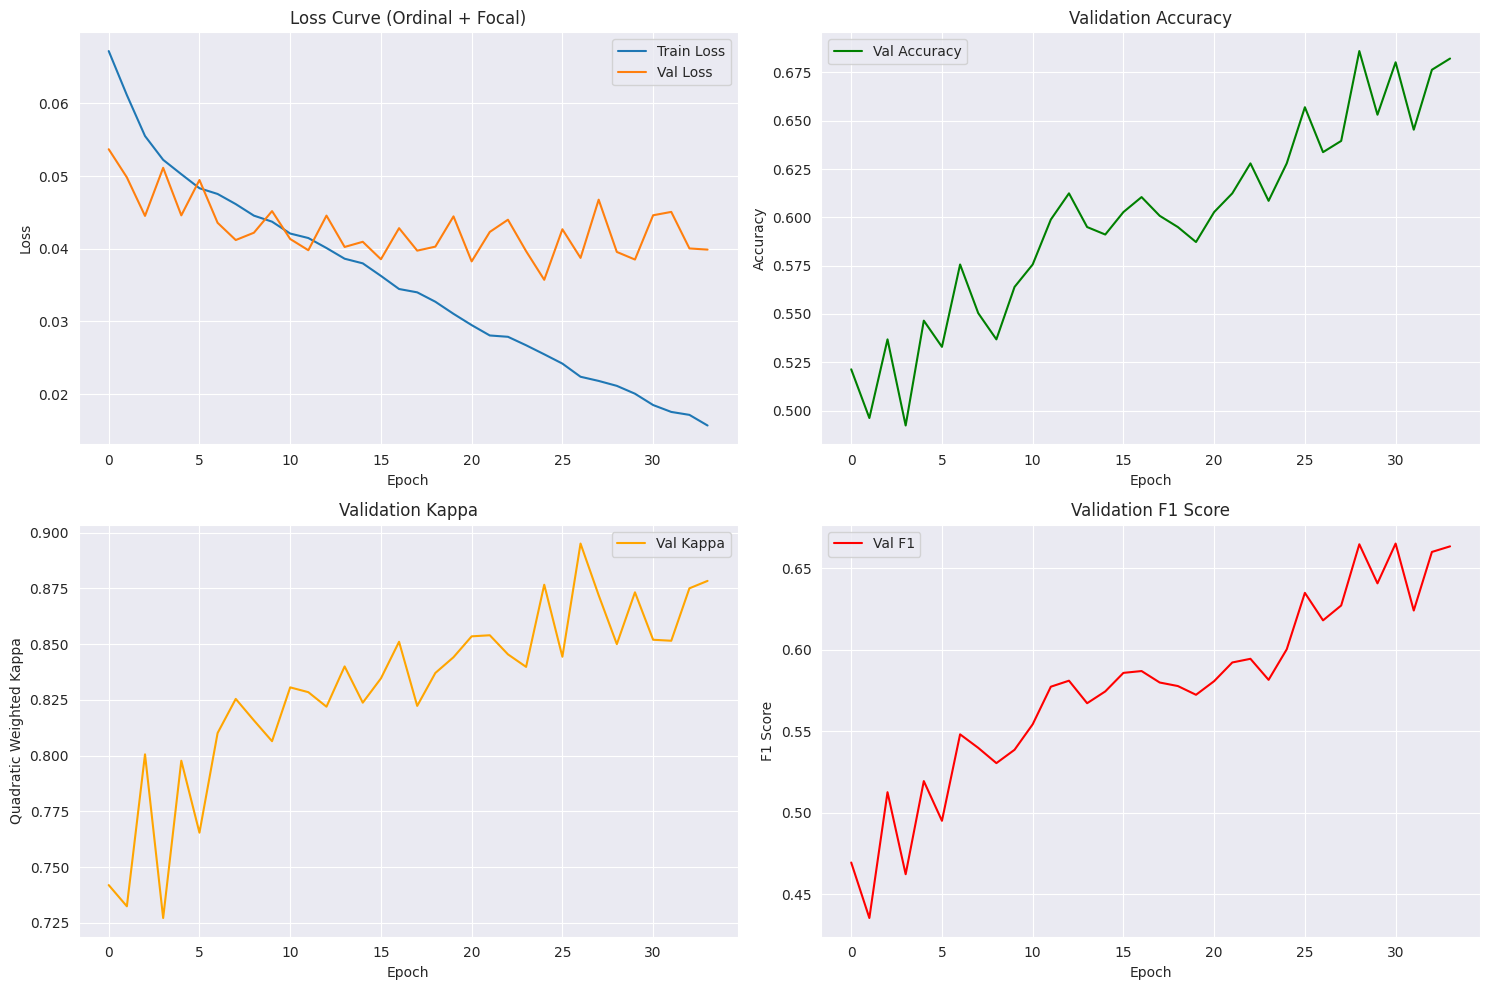

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Ordinal + Focal)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-2-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 1818/1818 [04:38<00:00,  6.53it/s]



TEST SET RESULTS (Ordinal + Focal Loss)
Accuracy: 22.87%
Quadratic Weighted Kappa: 0.1669
Macro F1 Score: 0.2154

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.6898    0.2114    0.3237      1925
      ISUP 1     0.5466    0.1650    0.2535      1812
      ISUP 2     0.1962    0.1228    0.1510       668
      ISUP 3     0.0675    0.2785    0.1086       316
      ISUP 4     0.1363    0.5250    0.2164       480
      ISUP 5     0.1599    0.4741    0.2392       251

    accuracy                         0.2287      5452
   macro avg     0.2994    0.2961    0.2154      5452
weighted avg     0.4725    0.2287    0.2534      5452


Confusion Matrix:
[[407 160  91 324 693 250]
 [139 299 216 566 470 122]
 [ 20  50  82 230 202  84]
 [  7   9  16  88 141  55]
 [ 15  23  10  66 252 114]
 [  2   6   3  30  91 119]]


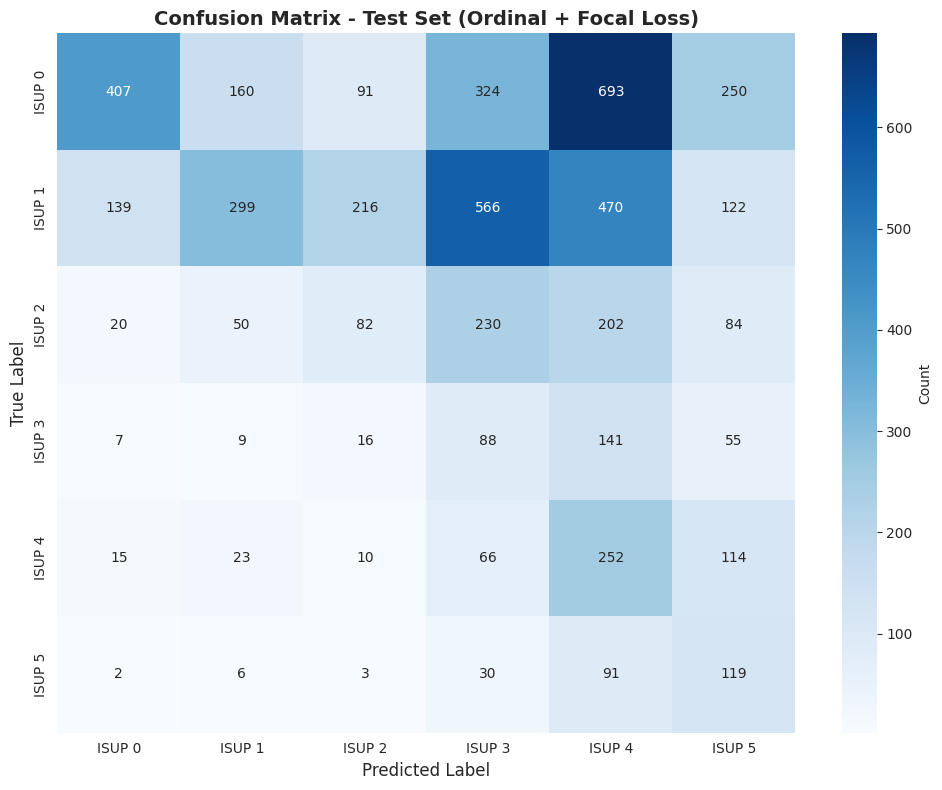


Test results saved to logs/b0-entropy-ordinal-focal-2-test-results.txt


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal Loss)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-2-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('logs/b0-entropy-ordinal-focal-2-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-2-test-results.txt")

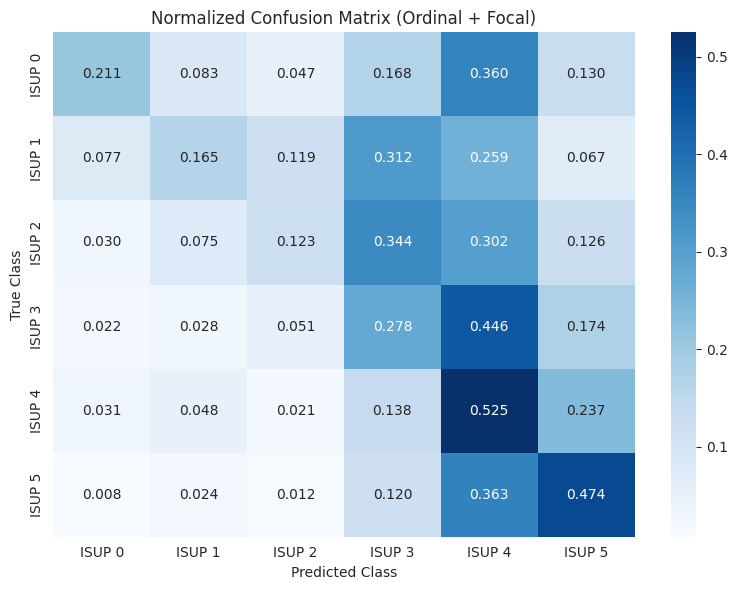

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels for classes
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Normalized Confusion Matrix (Ordinal + Focal)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-2-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

This notebook trained EfficientNet-B0 with a powerful combination of techniques:

1. **Entropy filtering** - Removed top 20% most difficult/ambiguous samples for cleaner training
2. **Ordinal loss** - Enforced the natural ordering of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
3. **Focal loss** - Down-weighted easy examples and focused learning on hard misclassifications

### How the combined loss works:

- **Ordinal encoding**: Each ISUP grade k is converted to k binary thresholds
  - ISUP 0: [0,0,0,0,0]
  - ISUP 3: [1,1,1,0,0] (grade > 0, > 1, > 2, but not > 3 or > 4)

- **Focal modulation**: Applied to each binary threshold prediction
  - Easy predictions (high confidence): Down-weighted by factor (1-p)^gamma
  - Hard predictions (low confidence): Retain full weight
  - Result: Model focuses on learning difficult threshold boundaries

### Expected benefits:

- Better handling of class imbalance (fewer high-grade samples)
- Reduced impact of easy negative examples
- Improved performance on minority classes (ISUP 4-5)
- Maintained ordinal consistency in predictions